# Assignment 3 - Abramov Aleksandr. Question 1

Implement a simplified Capsule Network layer in PyTorch or TensorFlow. You
must manually implement the Dynamic Routing algorithm (the iterative process of updating
coupling coefficients bij and calculating output vectors vj ) rather than using a high-level
library. Train this network on the MNIST or Fashion-MNIST dataset. Show the classification
accuracy and the number of routing iterations required for convergence. 

In [ ]:
import torch
import torch.nn.functional as torch_func

def squashing(
    input: torch.Tensor, dim: int = -1, eps: float = 1e-8
) -> torch.Tensor: # (B, num_caps, caps_size)
    norms = (input ** 2).sum(dim=dim, keepdim=True) # (B, num_caps, 1)
    coef = (norms / (1 + norms))
    vecs = (input / torch.sqrt(norms + eps))
    return coef * vecs # (B, num_caps, caps_size)

class PrimaryCaps(torch.nn.Module):
    def __init__(
        self, n_ch: int = 256, num_caps: int = 32, caps_size: int = 8
    ):
        super().__init__()
        self.num_caps = num_caps
        self.caps_size = caps_size
        self.conv = torch.nn.Conv2d(
            n_ch, num_caps * caps_size, kernel_size=9, stride=2
        )
    
    def forward(self, input: torch.Tensor): # (B, 256, 20, 20)
        input = self.conv(input) # (B, 32*8, 6, 6)
        input = input.view(
            -1, self.num_caps, self.caps_size, *input.shape[-2:]
        ) # (B, 32, 8, 6, 6)
        return input.permute(0, 1, 3, 4, 2) # (B, 32, 6, 6, 8)

class DigitCaps(torch.nn.Module):
    def __init__(
        self,
        in_caps_size: int = 8,
        num_caps_out: int = 10,
        out_caps_size: int = 16,
        routing_iterations: int = 3,
    ):
        super().__init__()
        self.W = None
        self.in_caps_size = in_caps_size
        self.num_caps_out = num_caps_out
        self.out_caps_size = out_caps_size
        self.routing_iterations = routing_iterations

    def forward(self, input: torch.Tensor): # (B, N = 32*6*6, 8)
        if self.W is None:
            self.num_caps_in = input.shape[1]
            W = torch.randn(
                self.num_caps_in,
                self.num_caps_out,
                self.out_caps_size,
                self.in_caps_size,
                device=input.device
            )
            self.W = torch.nn.Parameter(0.01 * W)
        input = input.unsqueeze(2).unsqueeze(-1) # (B, N, 1, 8, 1)
        u_hat = torch.matmul(self.W, input).squeeze() # (B, N, 10, 16)
        
        b = torch.zeros(u_hat.shape[:3]).to(input.device) # (B, N, 10)
        for iter in range(self.routing_iterations):
            c = torch_func.softmax(b, dim=-1) # (B, N, 10)
            s = (c.unsqueeze(-1) * u_hat).sum(dim=1) # (B, 10, 16)
            v = squashing(s) # (B, 10, 16)
            b += torch.linalg.vecdot(u_hat, v.unsqueeze(1))
        return v

class CapsNet(torch.nn.Module):
    def __init__(self, routing_iterations: int = 3):
        super().__init__()
        self.conv1 = torch.nn.Conv2d(1, 256, kernel_size=9)
        self.primary_caps = PrimaryCaps()
        self.digit_caps = DigitCaps(
            routing_iterations=routing_iterations
        )
        
    def forward(self, input: torch.Tensor): # input: (B, 1, 28, 28)
        input = torch_func.relu(self.conv1(input)) # (B, 256, 20, 20)
        input = self.primary_caps(input) # (B, 32, 6, 6, 8)
        input = input.flatten(start_dim=1, end_dim=3) # (B, 32*6*6, 8)
        input = self.digit_caps(squashing(input)) # (B, 10, 16)
        return torch.linalg.vector_norm(input, dim=-1) # (B, 10)
    
def margin_loss(
    y_pred: torch.Tensor, y_true: torch.Tensor
) -> torch.Tensor:
    y_onehot = torch_func.one_hot(y_true, num_classes=y_pred.shape[1])
    L_pos = y_onehot * (torch_func.relu(0.9 - y_pred) ** 2)
    L_neg = (1 - y_onehot) * (torch_func.relu(y_pred - 0.1) ** 2)
    return (L_pos + 0.5 * L_neg).sum(dim=1).mean()

In [ ]:
import torchvision
import torchvision.transforms.v2
from torch.utils.data import DataLoader

transforms = torchvision.transforms.v2.Compose([
    torchvision.transforms.v2.ToImage(),
    torchvision.transforms.v2.ToDtype(torch.float32, scale=True),
    torchvision.transforms.v2.Normalize((0.1307,), (0.3081,)),
])
train_ds = torchvision.datasets.MNIST(
    "mnist", train=True, download=True, transform=transforms
)
test_ds = torchvision.datasets.MNIST(
    "mnist", train=False, download=True, transform=transforms
)

train_dl = DataLoader(train_ds, batch_size=128, shuffle=True)
test_dl = DataLoader(test_ds, batch_size=128, shuffle=False)

In [ ]:
import numpy
import scipy.special
import sklearn.metrics

def estimate_quality(
    y_pred_logits: numpy.ndarray, y_true: numpy.ndarray
) -> dict:
    y_pred_proba = scipy.special.softmax(y_pred_logits, axis=1)
    y_pred = numpy.argmax(y_pred_proba, axis=1)
    return {
        "Accuracy": sklearn.metrics.accuracy_score(y_true, y_pred),
        "AUC-ROC": sklearn.metrics.roc_auc_score(
            y_true, y_pred_proba, multi_class="ovo"
        ),
        "Precision": sklearn.metrics.precision_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "Recall": sklearn.metrics.recall_score(
            y_true, y_pred, average="macro"
        ),
        "F1-score": sklearn.metrics.f1_score(
            y_true, y_pred, average="macro"
        ),
        "TOP-5 Accuracy": sklearn.metrics.top_k_accuracy_score(
            y_true, y_pred_proba, k=5
        )
    }

def set_random_seed(seed: int = 42):
    numpy.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True

In [ ]:
import tqdm

device = torch.device('cuda')

def train_eval(routing_iterations: int, epochs: int = 5):
    set_random_seed(42)
    model = CapsNet(routing_iterations=routing_iterations).to(device)
    optimizer = torch.optim.AdamW(model.parameters())

    pbar = tqdm.trange(epochs)
    history = []
    for epoch in pbar:
        model.train()
        for X, y in train_dl:
            optimizer.zero_grad()
            pred = model(X.to(device))
            loss = margin_loss(pred, y.to(device))
            loss.backward()
            optimizer.step()

        model.eval()
        test_preds, test_targets = [], []
        for X, y in test_dl:
            test_targets.extend(y.tolist())
            with torch.no_grad():
                test_preds.extend(model(X.to(device)).cpu().tolist())
        metrics = estimate_quality(
            numpy.array(test_preds), numpy.array(test_targets)
        )
        pbar.set_postfix(metrics)
        history.append(metrics)
    return history

In [5]:
ROUTING_ITERATIONS = list(range(1, 10))

results = []
for routing_iterations in ROUTING_ITERATIONS:
    results.append(train_eval(routing_iterations))

100%|██████████| 5/5 [10:07<00:00, 121.41s/it, Accuracy=0.981, AUC-ROC=1, Precision=0.981, Recall=0.981, F1-score=0.981, TOP-5 Accuracy=1]        


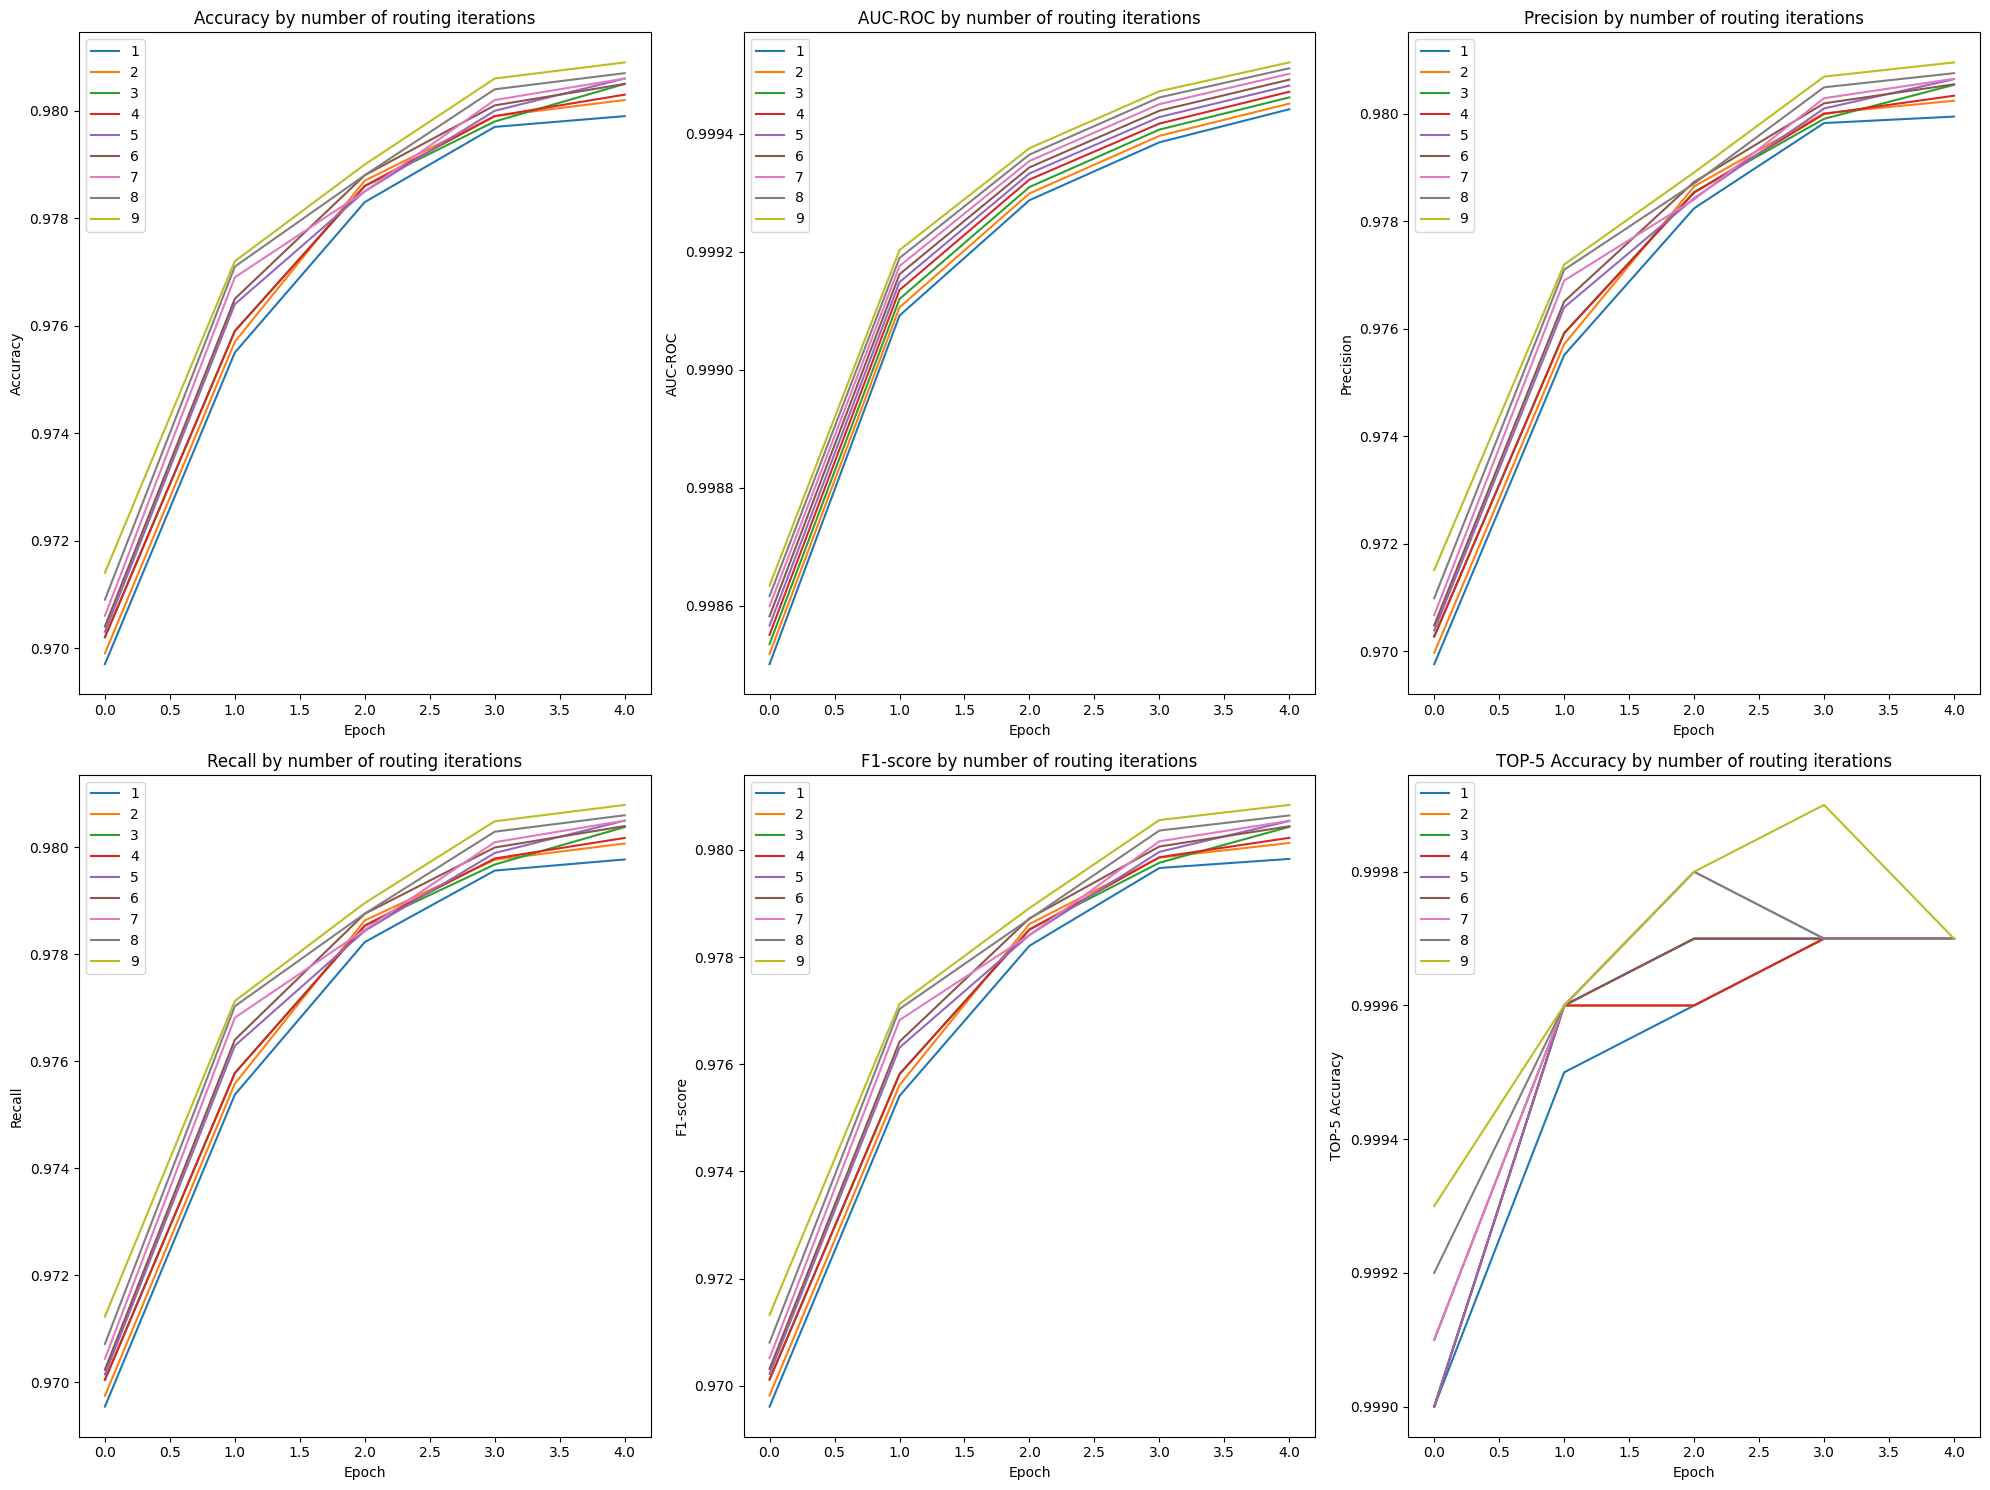

In [ ]:
import matplotlib.pyplot as plt

def draw_metric(metric: str, ax):
    for routing_iterations, run in enumerate(results, start = 1):
        ax.plot(
            range(len(run)),
            [epoch[metric] for epoch in run], label=routing_iterations
        )
        ax.set_title(f"{metric} by number of routing iterations")
        ax.set_xlabel("Epoch")
        ax.set_ylabel(metric)
        ax.legend()

fig, axes = plt.subplots(2, 3, figsize=(20, 15))
draw_metric("Accuracy", axes[0][0])
draw_metric("AUC-ROC", axes[0][1])
draw_metric("Precision", axes[0][2])
draw_metric("Recall", axes[1][0])
draw_metric("F1-score", axes[1][1])
draw_metric("TOP-5 Accuracy", axes[1][2])
fig.tight_layout()

The capsule network achieved over $98\%$ accuracy with any number of routing iterations between 1 and 9. Although the difference is minor due to the simplicity of the dataset, increasing the number of routing iterations tends to improve the model's performance. Nonetheless, one routing iteration is enough for convergence in this simple experiment.